# Objectif de ce notebook
1. Evaluer la qualité des datasets générés par 0_generate_dataset.ipynb
2. Explorer les données des datasets

# Importer toutes les libraries nécessaires avec la cellule suivante

In [54]:
import numpy as np
import pandas as pd
import random
import string



# ****Etude de fiabilité du fichier item_dataset.csv****
### Objectif :
- S'assurer que le jeu de données est assez pertinent pour pouvoir entrainer un modèle de ML
- S'assurer qu'il y ait assez d'items de chaque catégorie
- Checkez la distribution des notes
- Regardez les corrélations entre features
- Analyse par catégorie de puits
- Utiliser des modèles simples pour tester

## Afficher les premières lignes du dataset

In [55]:
df = pd.read_csv("../data/processed/item_dataset.csv")
df.head()

,item_name,pui_category,nb_stats,nb_perfect_lines,nb_high_ratio,nb_overs,total_weight,exo_weight,over_weight,avg_ratio,...,nb_resistance_pourcent_ratio,nb_dommage_elem_ratio,nb_dommage_pourcent_ratio,note,exo,over,puit,quality,template_name,config_case
0,Item_JBMIW,moyen,8,4,4,0,841.8,0.0,0,0.989866,...,0.0,0.0,0.0,100,False,False,moyen,très bon jet,Item_JBMIW,parfait
1,Item_JBMIW,moyen,8,6,2,0,843.8,0.0,0,0.997604,...,0.0,0.0,0.0,100,False,False,moyen,très bon jet,Item_JBMIW,parfait
2,Item_JBMIW,moyen,8,4,4,0,841.8,0.0,0,0.989866,...,0.0,0.0,0.0,100,False,False,moyen,très bon jet,Item_JBMIW,parfait
3,Item_JBMIW,moyen,8,6,2,0,843.0,0.0,0,0.993750,...,0.0,0.0,0.0,100,False,False,moyen,très bon jet,Item_JBMIW,parfait
4,Item_JBMIW,moyen,8,6,2,0,845.8,0.0,0,0.995521,...,0.0,0.0,0.0,100,False,False,moyen,très bon jet,Item_JBMIW,parfait


## Checker grossièrement avec describe()

In [56]:
df.describe()

,nb_stats,nb_perfect_lines,nb_high_ratio,nb_overs,total_weight,exo_weight,over_weight,avg_ratio,nb_basic_stats_ratio,nb_essential_stats_ratio,nb_secondary_stats_ratio,nb_heavy_stats_ratio,nb_résistance_elem_ratio,nb_resistance_pourcent_ratio,nb_dommage_elem_ratio,nb_dommage_pourcent_ratio,note
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,7.040000,2.559400,1.582700,0.195500,707.363065,6.762475,12.273700,0.874617,0.365242,0.120849,0.190861,0.187079,0.091341,0.069456,0.039079,0.019048,82.447750
std,1.593276,2.175318,1.527572,0.518646,290.885457,14.369072,53.850081,0.215296,0.098286,0.109338,0.111734,0.106178,0.102927,0.087236,0.071406,0.053272,20.091042
min,2.000000,0.000000,0.000000,0.000000,41.800000,0.000000,0.000000,0.275139,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,6.000000,0.000000,0.000000,0.000000,411.175000,0.000000,0.000000,0.812245,0.285714,0.000000,0.125000,0.125000,0.000000,0.000000,0.000000,0.000000,70.000000
50%,7.000000,2.000000,1.000000,0.000000,796.000000,0.000000,0.000000,0.949031,0.333333,0.125000,0.166667,0.142857,0.111111,0.000000,0.000000,0.000000,90.000000
75%,8.000000,4.000000,3.000000,0.000000,910.000000,0.000000,0.000000,0.994444,0.428571,0.166667,0.250000,0.250000,0.142857,0.125000,0.100000,0.000000,100.000000
max,10.000000,10.000000,8.000000,3.000000,1356.800000,101.000000,510.000000,1.862083,0.666667,0.444444,0.750000,0.500000,0.500000,0.333333,0.333333,0.333333,100.000000


## 1. Taille du dataset

In [57]:
df.shape

(20000, 27)

## 2 Balance des classes

In [58]:
df["config_case"].value_counts(normalize=True)

parfait         0.25
très bon jet    0.25
jet craft       0.25
jet nul         0.25
Name: config_case, dtype: float64

## 3. Distribution des notes
### 3.1. Distribution globale

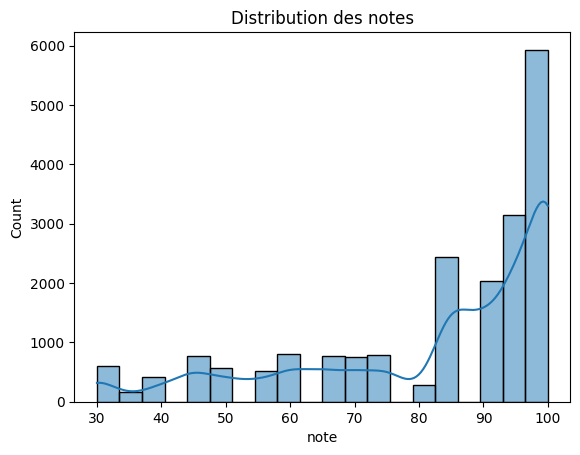

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['note'], bins=20, kde=True)
plt.title("Distribution des notes")
plt.show()

### 3.2. Distribution des notes par catégorie de puits

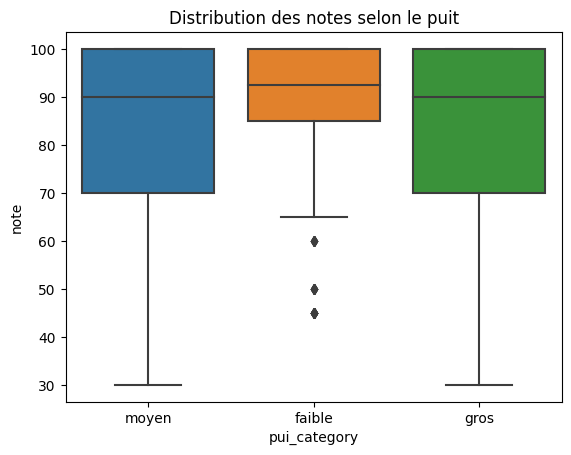

In [60]:
sns.boxplot(data=df, x='pui_category', y='note')
plt.title("Distribution des notes selon le puit")
plt.show()

## 4. Corrélation entre features

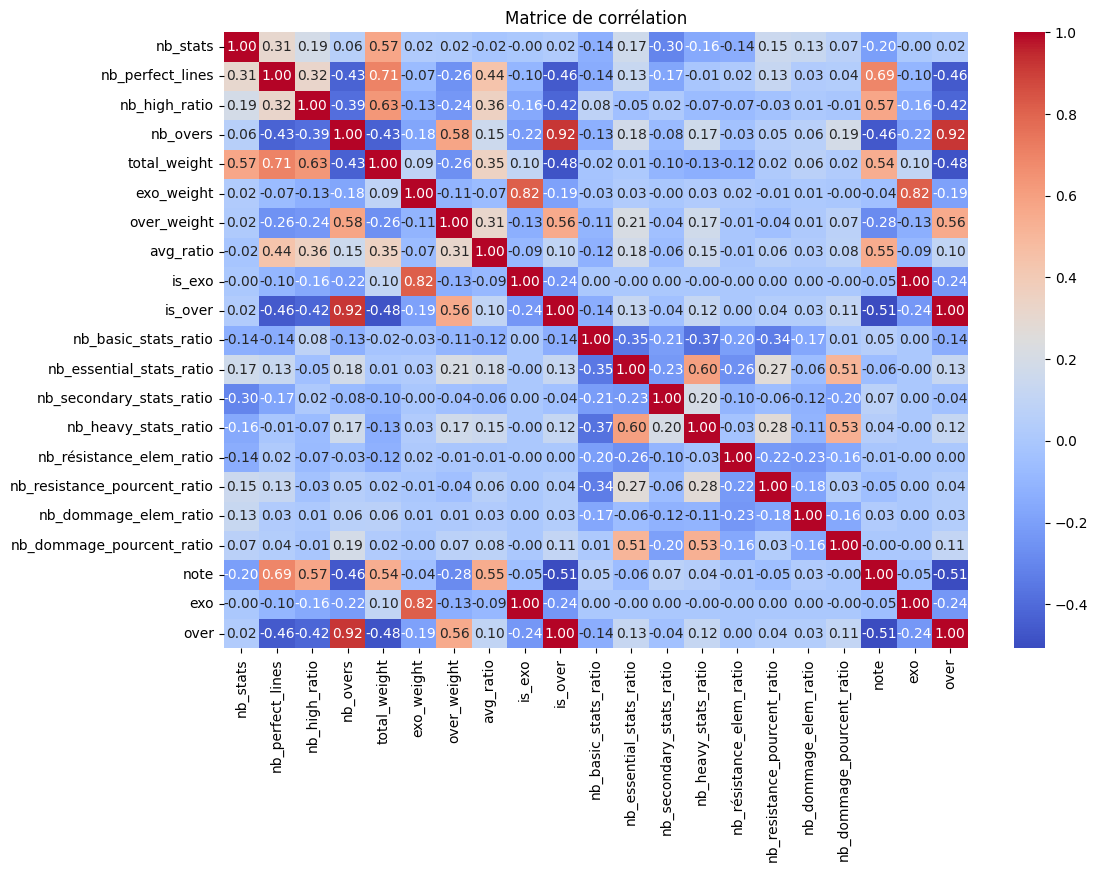

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


### 4.1. Corrélation note <-> stats parfaites

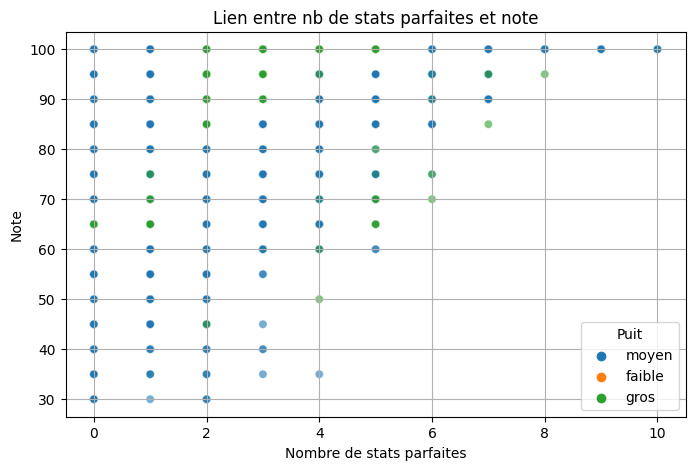

In [62]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="nb_perfect_lines", y="note", hue="pui_category", alpha=0.6)
plt.title("Lien entre nb de stats parfaites et note")
plt.xlabel("Nombre de stats parfaites")
plt.ylabel("Note")
plt.legend(title="Puit")
plt.grid(True)
plt.show()

## 5. Analyse par catégorie de puits

In [63]:
df.groupby("pui_category")["note"].mean()

pui_category
faible    89.950000
gros      82.857143
moyen     81.897414
Name: note, dtype: float64